<a href="https://colab.research.google.com/github/Jashed-20/Dogs_cats_classifier/blob/main/dog_or_cat_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [17]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:11<00:00, 75.7MB/s]



In [19]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [20]:
from zipfile import ZipFile
dataset= '/content/dogs-vs-cats.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('the data is extracted')

the data is extracted


In [21]:
from zipfile import ZipFile
dataset= '/content/train.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('the data is extracted')

the data is extracted


In [22]:
import os
path, dirs, files =next(os.walk('/content/train'))
file_count =len(files)
print('number of images: ',file_count)

number of images:  25000


In [ ]:
file_names=os.listdir('/content/train')


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
from sklearn.model_selection import train_test_split

from google.colab.patches import cv2_imshow


<function matplotlib.pyplot.show(close=None, block=None)>

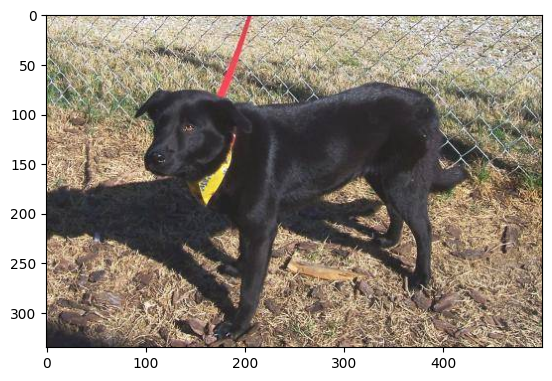

In [25]:
img = mpimg.imread('/content/train/dog.6345.jpg')
imgplt=plt.imshow(img)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

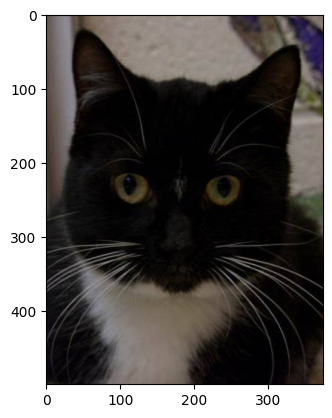

In [26]:
img = mpimg.imread('/content/train/cat.2714.jpg')
imgplt=plt.imshow(img)
plt.show

In [27]:
file_names=os.listdir('/content/train')
for i in range(5):
  name=file_names[i]
  print(name[0:3])

dog
dog
dog
cat
dog


In [30]:
os.mkdir('/content/image resized')

In [31]:
og_fol='/content/train'
resized_fol='/content/image resized'

In [32]:
for i in range(2000):
    filename = os.listdir(og_fol)[i]

    img_path = os.path.join(og_fol, filename)
    img = Image.open(img_path)

    img = img.resize((224, 224))
    img = img.convert('RGB')

    newImgPath = os.path.join(resized_fol, filename)
    img.save(newImgPath)

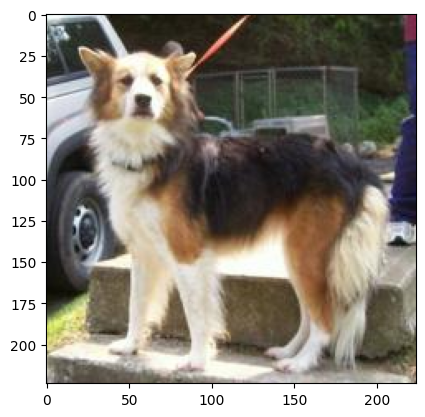

In [35]:
img= mpimg.imread('/content/image resized/dog.8391.jpg')
imgplt=plt.imshow(img)
plt.show()

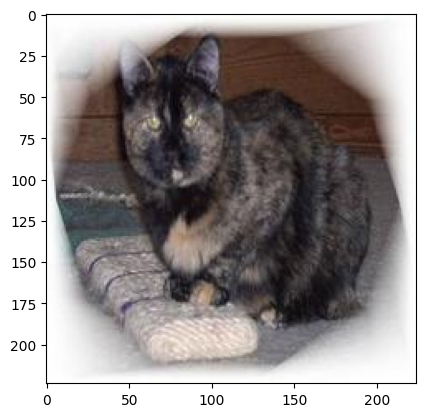

In [36]:
img= mpimg.imread('/content/image resized/cat.5369.jpg')
imgplt=plt.imshow(img)
plt.show()

**LABELLING THE RESIZED IMAGES**  
cat--0  
dog--1



In [39]:
filenames=os.listdir('/content/image resized')
labels=[]

for i in range(2000):
  file_name=filenames[i]
  label=file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)



In [40]:
print(labels[0:5])
print(len(labels))

[1, 1, 1, 0, 1]
2000


In [41]:
values,counts=np.unique(labels,return_counts=True)
print(values)
print(counts)

[0 1]
[1016  984]


**converting images to numpy array**

In [42]:
import cv2
import glob


In [49]:
image_direc='/content/image resized/'
image_extension=['png','jpg']

files=[]

[files.extend(glob.glob(image_direc +'*'+ e)) for e in image_extension]

dog_cat_images =np.asarray([cv2.imread(file) for file in files])

In [50]:
type(dog_cat_images)

numpy.ndarray

In [51]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [52]:
X=dog_cat_images
Y=np.asarray(labels)

In [54]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(X_train.shape)
print(X_test.shape)

(1600, 224, 224, 3)
(400, 224, 224, 3)


In [55]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

**building the neural network**


In [56]:
import tensorflow as tf
import tensorflow_hub as hub

In [57]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

In [58]:
base_model = MobileNet(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [59]:
for layer in base_model.layers:
    layer.trainable = False

In [60]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1, activation='sigmoid')
])

In [62]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [66]:
history = model.fit(
    X_train, Y_train,
    epochs=10,
    validation_data=(X_test, Y_test),
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.9638 - loss: 0.1113 - val_accuracy: 0.9525 - val_loss: 0.1123
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9756 - loss: 0.0803 - val_accuracy: 0.9550 - val_loss: 0.1041
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9806 - loss: 0.0672 - val_accuracy: 0.9625 - val_loss: 0.0861
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9844 - loss: 0.0557 - val_accuracy: 0.9700 - val_loss: 0.0798
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9875 - loss: 0.0481 - val_accuracy: 0.9675 - val_loss: 0.0787
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9887 - loss: 0.0425 - val_accuracy: 0.9725 - val_loss: 0.0752
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9906 - loss: 0.0377 - val_accuracy: 0.9725 - val_loss: 0.0704
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.9925 - loss: 0.0334 - val_accuracy: 0.9725 - v

In [67]:
print("Validation Accuracy per epoch:", history.history['val_accuracy'])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Validation Accuracy per epoch: [0.9524999856948853, 0.9549999833106995, 0.9624999761581421, 0.9700000286102295, 0.9674999713897705, 0.9725000262260437, 0.9725000262260437, 0.9725000262260437, 0.9725000262260437, 0.9750000238418579]
Final Validation Accuracy: 0.9750000238418579


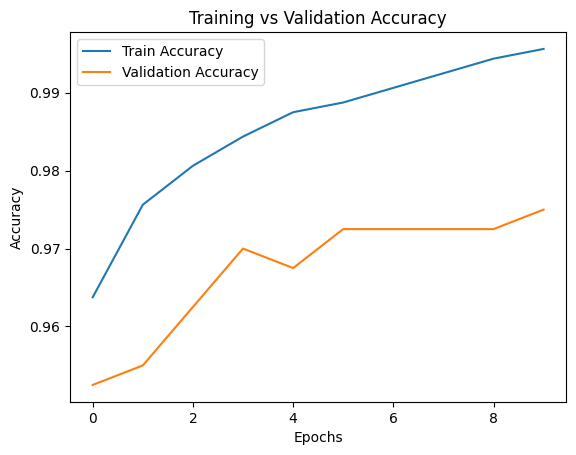

In [68]:

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

**Predictive System**

 path of the image to be predicted/content/cat.jpg


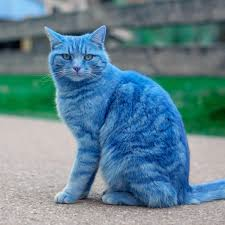

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
The image represents a Cat


In [77]:


input_image_path = input(' path of the image to be predicted')

input_image = cv2.imread(input_image_path)
input_image = cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

if input_pred_label == 0:
    print('The image represents a Cat')

else:
    print('The image represents a Dog')